In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns   
import pandas as pd
import numpy as np
from sklearn.metrics import precision_recall_curve,confusion_matrix, matthews_corrcoef, accuracy_score, precision_score, recall_score

In [61]:
def labeling(subset): #function that etiquettes the sequences if they present the signal peptide (SP) +, if not -, building a binary list

    label=[] #list of 1 if the seq is + or 0 if the seq is neg

    subset['positive/negative'] =np.where(subset['SP cleavage']=='False', '-','+')
    for row,seq in subset.iterrows():
        if seq['positive/negative']=="+":
            label.append(1)
        else:
            label.append(0)
    return label

In [62]:
subset_list=['subset1_arricchito.tsv','subset2_arricchito.tsv','subset3_arricchito.tsv','subset4_arricchito.tsv','subset5_arricchito.tsv'] #reading the 5 subset files 
subset={} #creating a dictionary whose keys will be the subset file names and the values Pandas dataframes
for i in range(len(subset_list)):
    subset[f'subset_{i+1}']=pd.read_csv(subset_list[i],sep="\t")

In [63]:
list_labels=[] #in order to prevent further errors like the following "found input variables with inconsistent numbers of samples: [1603, 1605]" we create a new dictionary with the subsets shifted
subset_for_labels = {'subset_1':subset['subset_1'],'subset_2':subset['subset_2'],'subset_3':subset['subset_3'],'subset_4':subset['subset_4'],'subset_5':subset['subset_5']}
for df in subset_for_labels.values():
    etiq = labeling(df)
    list_labels.append(etiq)

In [64]:
testing_set=pd.read_csv("/home/anomalocaris/LB2_project_group_9/Data Preparation/benchmark_arricchito.tsv",sep="\t") #il benchmark è il testing set

In [91]:
def file_set_creator(subset_dict,testing_set):
    """
    This function takes in input a dictionary of Pandas Dataframes and cycles through the length of the dictionary
    creating at each iteration a training_list (3 subsets of positive sequences concatenated), 1 validation list (positive and negative
    sequences) and 1 testing list (positive and negative sequences to test the model)
    """
    training_list = []
    validation_list = []
    testing_list = []
    keys = list(subset_dict.keys())   # elenco delle chiavi: ["subset_1", ..., "subset_5"]
    n = len(keys)

    
    # --- Training: 4 DataFrame
    training_keys = [keys[0], keys[1], keys[2],keys[3]]
    training_dfs = [subset_dict[k] for k in training_keys]
    training = pd.concat(training_dfs, ignore_index=True)
    pos_seq = []

    positive_df = training[training['SP cleavage'] != 'False']
    
    for _, row in positive_df.iterrows():
        sequence = row["Sequence"]
        cleavage = int(row["SP cleavage"])
        # estraggo la porzione di interesse
        pos_seq.append(sequence[cleavage-13:cleavage+2])
    training_list=pos_seq


    # --- Validation: 1 DataFrame
    validation_key = keys[4]
    validation = subset_dict[validation_key]
    seq_val_90=[]
    for index,row in validation.iterrows(): 
        sequence=row["Sequence"]
        seq_val_90.append(sequence[:90])
    validation_list=seq_val_90
    

    # --- Testing: 1 DataFrame (benchmark dataframe)
    
    seq_test_90=[]
    for index,row in testing_set.iterrows(): 
        sequence=row["Sequence"]
        seq_test_90.append(sequence[:90])
    testing_list=seq_test_90   

    return pos_seq,validation_list,testing_list

In [89]:
train,val,test = file_set_creator(subset,testing_set)

In [ ]:
def init_matrix (window): #function that initialise the PSPM matrix, with pseudocounts. 
    aminoacids = ["A","R","N","D","C","Q","E","G","H","I","L","K","M","F","P","S","T","W","Y","V"]
    dict_mat = {}
    for i in aminoacids:
        dict_mat[i]= [1 for i in range(window)]
    return dict_mat

In [69]:
def compute_pswm (matrix,list_seq): #function that used the PSPM matrix and a list of sequences and computes the PSWM. Built as a dictionary of lists
    diz_swp = {'A':0.08, 'R':0.06, 'N':0.04, 'D':0.06, 'C':0.01, 'Q':0.04, 'E':0.07, 'G':0.07, 'H':0.02, 'I':0.06, 'L':0.10, 'K':0.06, 'M':0.02, 'F':0.04, 'P':0.05, 'S':0.07, 'T':0.05, 'W':0.01, 'Y':0.03, 'V':0.07} #frequency of residues from SwissProt
    for seq in list_seq:
        for index,res in enumerate(seq):
          if res not in matrix: #if residues different from the ones in the SwissFreq dictionary appear, they are skipped
              continue
          matrix[res][index]+=1
    
    div = int(len(list_seq))+20

    
    for key in matrix:
        matrix[key] = [np.log2(x/(div*diz_swp[key])) for x in matrix[key]]

    return matrix

In [70]:
def score_window(matrix, seq_window):
    """
    It's the function that calculates the position-specific score of an amino acid window with respect to the PSWM (Position-Specific Weight Matrix) —
    it's then used to slide across the entire sequence and find the point with the highest score, which most likely corresponds to the signal peptide region.
    """
    score = 0 # Initialize the total score to zero,this will accumulate the sum
    for pos in range(len(seq_window)):
        letter = seq_window[pos]
        if letter in matrix:
            # Add the corresponding weight from the PSWM for this amino acid
            # at the specific position to the running total score
            score += matrix[letter][pos]
    return score


In [82]:
def train_and_score(training, validation):
    # Access global labels for validation sequences
    global val_labels

    # Initialize and build the PSWM from the training set
    matrix = init_matrix(15)
    PSWM = compute_pswm(matrix, training)

    final_score = []

    # Score each validation sequence
    for seq in validation:
        if len(seq) < 15:
            continue
        scores_seq = [
            score_window(PSWM, seq[i:i + 15])
            for i in range(len(seq) - 14)
        ]
        final_score.append(max(scores_seq))

    # Evaluate performance on validation data
    precision, recall, thresholds = precision_recall_curve(val_labels, final_score)
    fscore = (2 * precision * recall) / (precision + recall) #F1-score
    optimal_threshold = thresholds[np.argmax(fscore)]

    return PSWM, optimal_threshold


In [ ]:
train_labels = list_labels[0]+list_labels[1]+list_labels[2]+list_labels[3]
val_labels=list_labels[4]
PSWM_matrix_final, optimal_threshold = train_and_score(train, val)


In [92]:
def testing(matrix, th, testing_set):
    """
    Calculates the maximum PSWM score (using 15-aa windows) for each sequence 
    in the testing set and classifies them based on a threshold.
    Returns:
        final_score: list of maximum scores per sequence
        y_pred_test: list of binary predictions (1 if score >= threshold, else 0)
    """
    final_score = []

    # Iterate over each sequence in the testing set (~90 amino acids each)
    for seq in testing_set:
        # Skip sequences shorter than the 15-aa window
        if len(seq) < 15:
            continue

        scores_seq = []
        # Slide a 15-aa window across the sequence
        for i in range(len(seq) - 14):
            window = seq[i:i + 15]                # extract 15-aa subsequence
            score = score_window(matrix, window)  # compute PSWM score for this window
            scores_seq.append(score)

        # Keep the maximum score found in the sequence
        max_score = max(scores_seq)
        final_score.append(max_score)

    # Generate binary predictions: 1 if score ≥ threshold, else 0
    y_pred_test = [int(s >= th) for s in final_score]

    # Return both the raw scores and their binary predictions
    return final_score, y_pred_test

In [93]:
fs, yp = testing(PSWM_matrix_final,optimal_threshold,test)


=== TEST SET METRICS ===
MCC        = 0.712
Precision  = 0.772
Accuracy   = 0.946
Sensitivity= 0.712
Confusion Matrix:
 [[1741   46]
 [  63  156]]


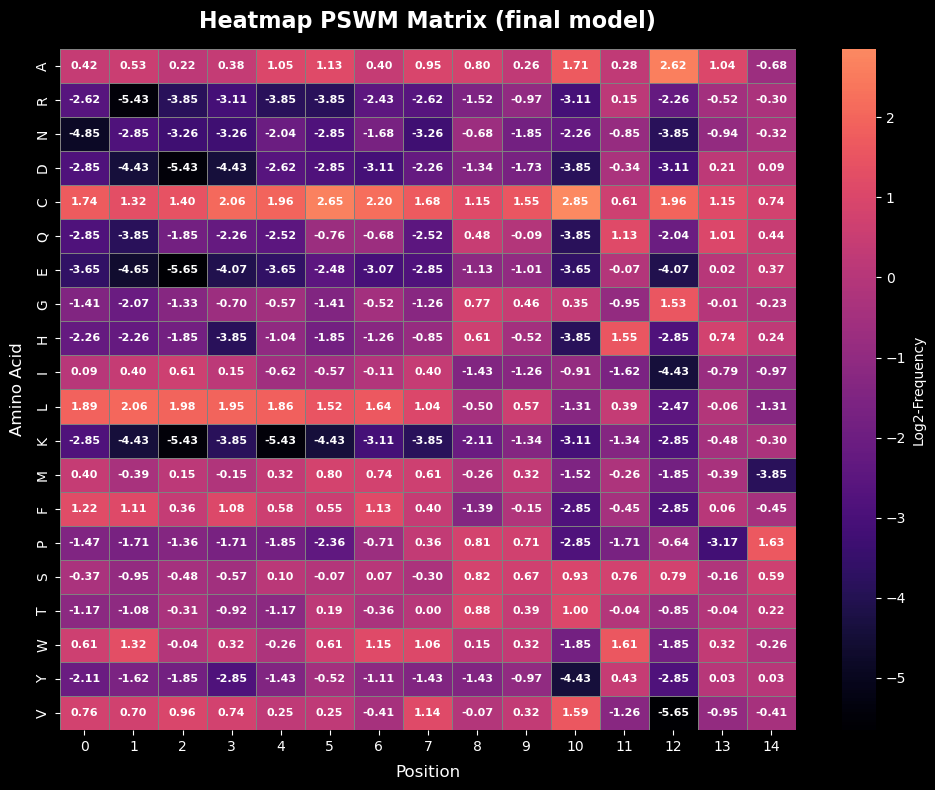

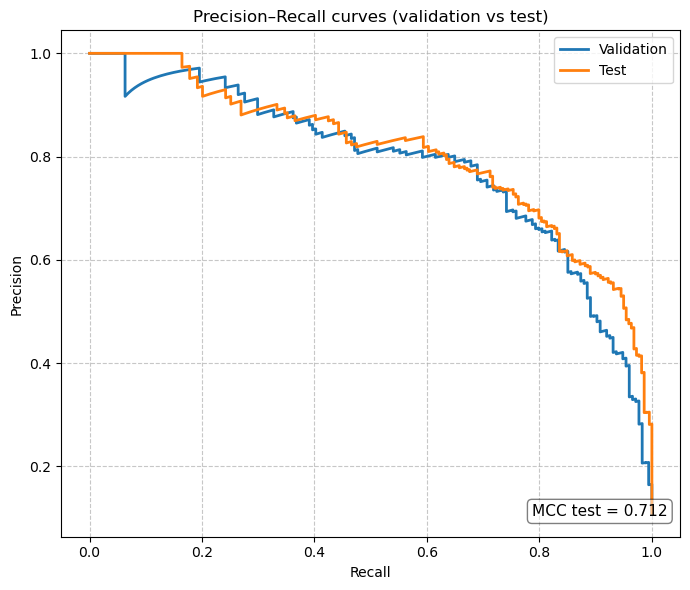

In [101]:
# === LABELS PER IL TEST SET (benchmark) ===
labels_test = labeling(testing_set)  # stesso schema di labeling usato per i subset 1–5

# === METRICHE SUL TEST ===
mcc_test = matthews_corrcoef(labels_test, yp)
prec_test = precision_score(labels_test, yp)
acc_test = accuracy_score(labels_test, yp)
sens_test = recall_score(labels_test, yp)
cm_test = confusion_matrix(labels_test, yp)

print("\n=== TEST SET METRICS ===")
print(f"MCC        = {mcc_test:.3f}")
print(f"Precision  = {prec_test:.3f}")
print(f"Accuracy   = {acc_test:.3f}")
print(f"Sensitivity= {sens_test:.3f}")
print("Confusion Matrix:\n", cm_test)

# === HEATMAP PSWM (dark) ===
plt.style.use("dark_background")
df_matrix = pd.DataFrame(PSWM_matrix_final).T  # aminoacidi come righe

plt.figure(figsize=(10, 8))
sns.heatmap(
    df_matrix,
    annot=True,
    fmt=".2f",
    cmap="magma",
    center=0,
    linewidths=0.4,
    linecolor="gray",
    annot_kws={"size": 8, "color": "white", "weight": "bold"},
    cbar_kws={"label": "Log2-Frequency"},
)
plt.title("Heatmap PSWM Matrix (final model)", fontsize=16, fontweight="bold", pad=15, color="white")
plt.xlabel("Position", fontsize=12, labelpad=8, color="white")
plt.ylabel("Amino Acid", fontsize=12, labelpad=8, color="white")
plt.xticks(fontsize=10, rotation=0, color="white")
plt.yticks(fontsize=10, color="white")
plt.tight_layout()
plt.savefig("heatmap_pswm_matrix_final_dark.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()
plt.style.use("default")

#PR CURVE SUL TEST (con soglia ottimale scelta su validation) 
prec_curve_test, rec_curve_test, thr_curve_test = precision_recall_curve(labels_test, fs)

plt.figure(figsize=(6, 5))
plt.plot(rec_curve_test, rec_curve_test, label="PR curve (test)", linewidth=2)

# Trova il punto del test-set la cui soglia è più vicina alla soglia ottimale trovata su validation
best_thr_idx_test = min(range(len(thr_curve_test)), key=lambda j: abs(thr_curve_test[j] - optimal_threshold))

plt.scatter(
    rec_curve_test[best_thr_idx_test],
    prec_curve_test[best_thr_idx_test],
    s=80,
    label=f"Best thr (val) = {optimal_threshold:.3f}",
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall curve (test set)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)

# === MCC nel grafico del TEST ===
plt.text(
    0.98, 0.05,
    f"MCC = {mcc_test:.3f}",
    fontsize=11,
    ha="right", va="center",
    transform=plt.gca().transAxes,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.5)
)

plt.tight_layout()
plt.savefig("pr_curve_test.png", dpi=300)
plt.close()

# === (OPZIONALE) PR CURVE: VALIDATION vs TEST ===
# riuso la funzione testing per calcolare i punteggi sulla validation
val_scores, _ = testing(PSWM_matrix_final, optimal_threshold, val)

prec_curve_val, rec_curve_val, _ = precision_recall_curve(val_labels, val_scores)

plt.figure(figsize=(7, 6))
plt.plot(rec_curve_val,  prec_curve_val,  linewidth=2, label="Validation")
plt.plot(rec_curve_test, prec_curve_test, linewidth=2, label="Test")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall curves (validation vs test)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)

# MCC nel grafico VAL vs TEST
plt.text(
    0.98, 0.05,
    f"MCC test = {mcc_test:.3f}",
    fontsize=11,
    ha="right", va="center",
    transform=plt.gca().transAxes,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.5)
)

plt.tight_layout()
plt.savefig("r_curve_val_vs_test.png", dpi=300)
plt.show()
